In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("All libraries are working perfectly!")

All libraries are working perfectly!


In [50]:
# load ataset 
california = fetch_california_housing(as_frame=True)
df = california.frame  # Convert into DataFrame 

# Check First 5 rows 
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [51]:
# Rows, columns and data type check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [52]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


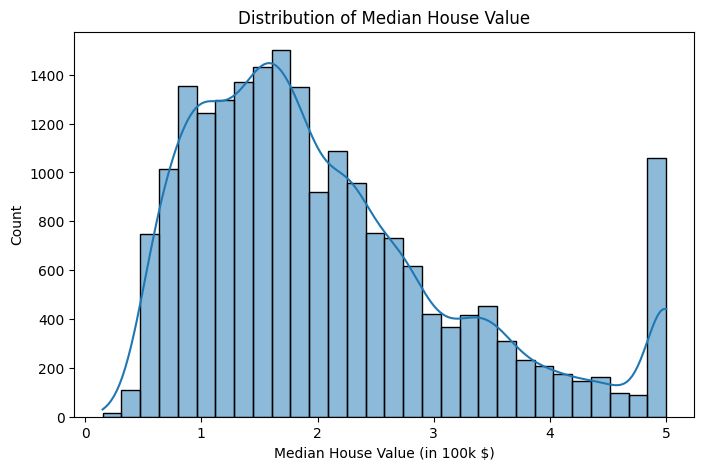

In [53]:
# Median House Value distribution
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (in 100k $)")
plt.show()

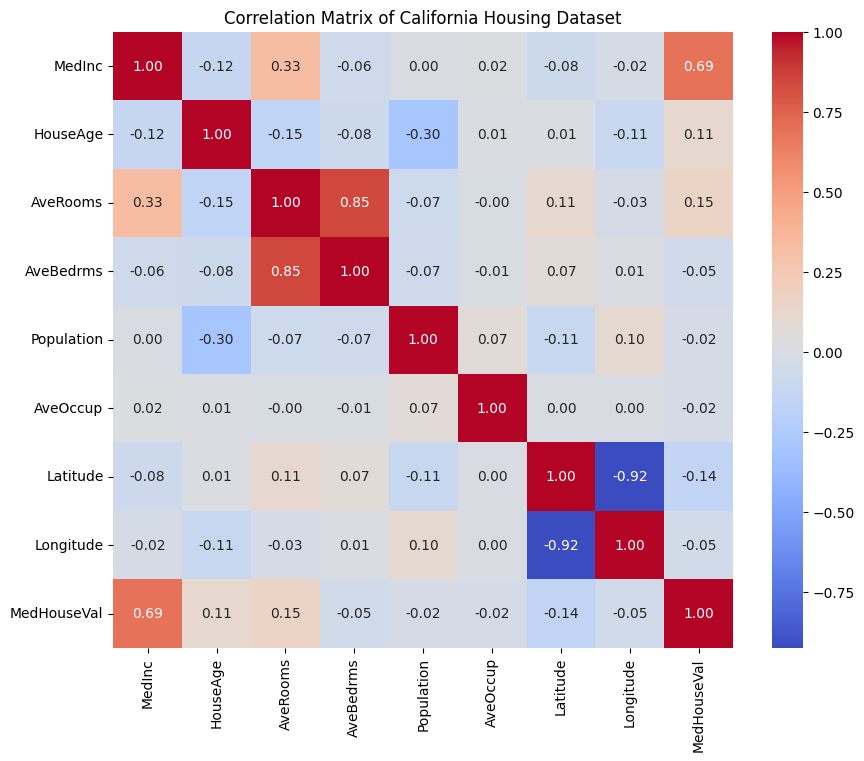

In [54]:
# correlation matrix of Features
corr = df.corr()

# Visualize With Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of California Housing Dataset")
plt.show()

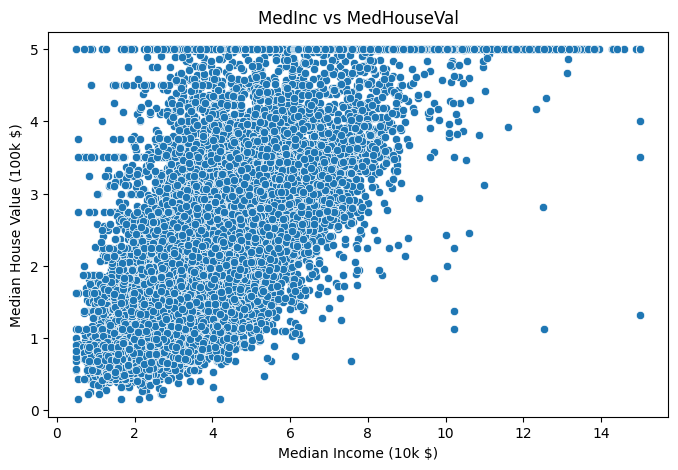

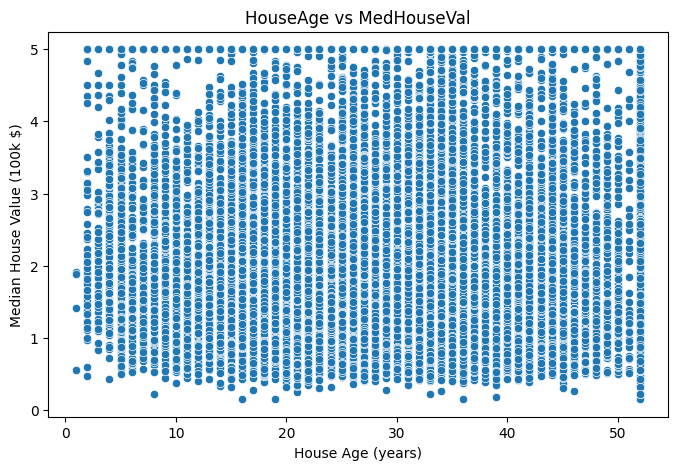

In [55]:
# Median Income vs Median House Value
plt.figure(figsize=(8,5))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.title("MedInc vs MedHouseVal")
plt.xlabel("Median Income (10k $)")
plt.ylabel("Median House Value (100k $)")
plt.show()

# House Age vs Median House Value
plt.figure(figsize=(8,5))
sns.scatterplot(x='HouseAge', y='MedHouseVal', data=df)
plt.title("HouseAge vs MedHouseVal")
plt.xlabel("House Age (years)")
plt.ylabel("Median House Value (100k $)")
plt.show()

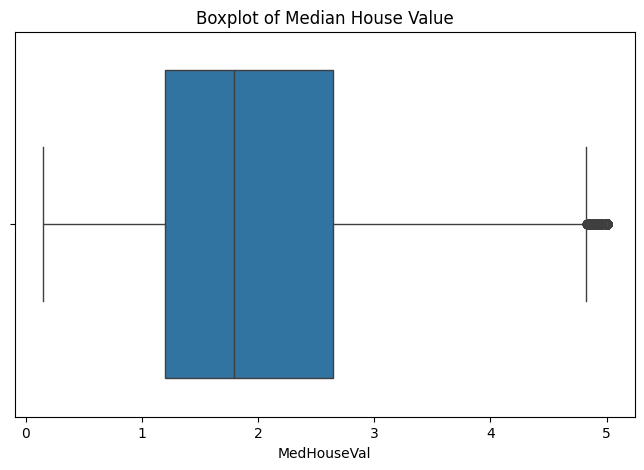

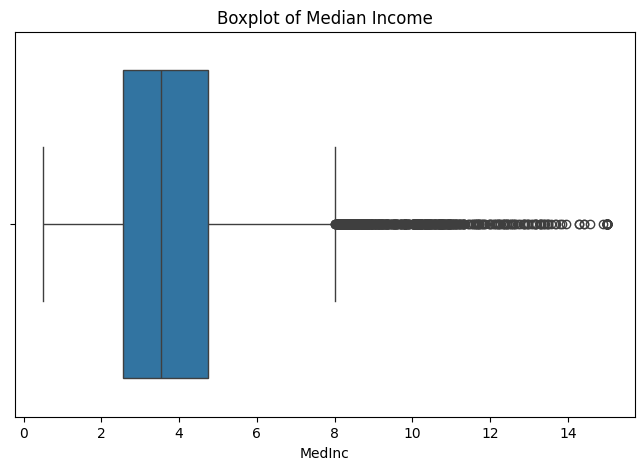

In [56]:
# Median House Value boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MedHouseVal'])
plt.title("Boxplot of Median House Value")
plt.show()

# Median Income boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MedInc'])
plt.title("Boxplot of Median Income")
plt.show()

In [57]:
# Features (X) and Target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [58]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)


In [59]:
# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [60]:
# Predictions on test data
y_pred = model.predict(X_test)

print("First 5 predictions:", y_pred[:5])

First 5 predictions: [0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [61]:
print("First 5 Actual values:", y_test[:5].values)

First 5 Actual values: [0.477   0.458   5.00001 2.186   2.78   ]


In [62]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.555891598695244
R2 Score: 0.5757877060324511


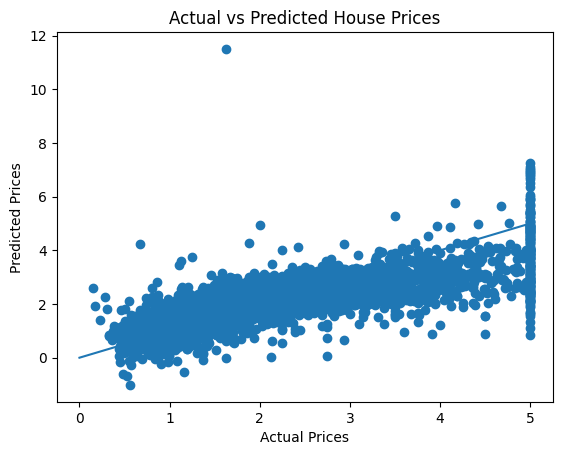

In [63]:
plt.scatter(y_test, y_pred)

plt.plot([0, 5], [0, 5])  # Perfect prediction line

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [66]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
rf_pred = rf_model.predict(X_test)

In [68]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MSE: 0.25602128637529376
Random Forest R2 Score: 0.8046248990761814


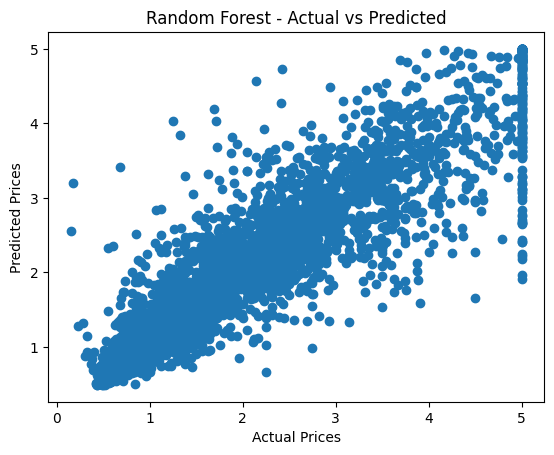

In [69]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

In [70]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

print(feature_importance_df)

      Feature  Importance
0      MedInc    0.524956
5    AveOccup    0.138478
6    Latitude    0.088976
7   Longitude    0.088624
1    HouseAge    0.054517
2    AveRooms    0.044241
4  Population    0.030716
3   AveBedrms    0.029492


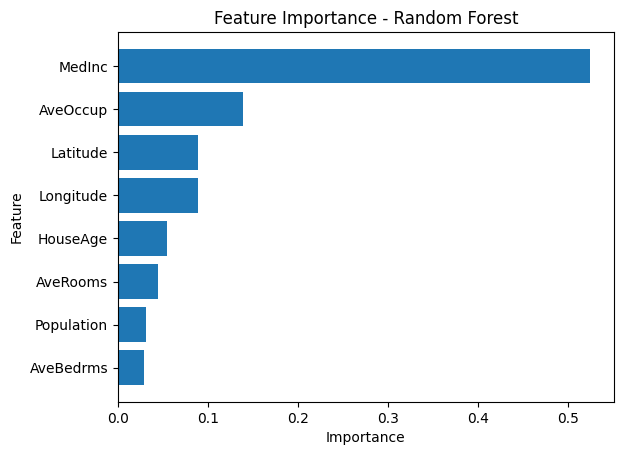

In [71]:
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [72]:
import pickle

# Save Linear Regression model
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Linear Regression model saved successfully!")

# Save Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Random Forest model saved successfully!")

Linear Regression model saved successfully!
Random Forest model saved successfully!
